# Chapter 8. Unsupervised Learning Techniques

Most real-world data is unlabeled.

In supervised learning, the training data includes both input features `X` and labels `y`. In unsupervised learning, the training data only contains the input features `X`, so the algorithm must discover useful structure on its own.

This is useful because labeling data can be expensive, slow, and sometimes require human experts.

In this chapter, we study three main unsupervised learning tasks:

- clustering
- anomaly detection
- density estimation

Chapter 7 already covered dimensionality reduction, another important unsupervised learning task.

This chapter starts with clustering algorithms such as k-means and DBSCAN, then moves on to Gaussian mixture models for density estimation, clustering, and anomaly detection.

## Clustering Algorithms: k-means and DBSCAN

Clustering groups similar instances into clusters without using target labels.

It is useful for tasks such as customer segmentation, anomaly detection, semi-supervised learning, and image segmentation.

Different algorithms define clusters differently: k-means looks for groups around centroids, while DBSCAN looks for dense regions.

### k-Means Clustering

The k-means algorithm is a simple and efficient clustering algorithm.

It works especially well when the data is composed of roughly round clusters, or blobs.

The goal of k-means is to find $k$ cluster centers, called centroids, and assign each instance to the closest centroid.

In [6]:
import os

# Avoid a KMeans memory leak warning on Windows with MKL
os.environ["OMP_NUM_THREADS"] = "6"

In [7]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Define five blob centers and their standard deviations
blob_centers = [
    [0.2, 2.3],
    [-1.5, 2.3],
    [-2.8, 1.8],
    [-2.8, 2.8],
    [-2.8, 1.3],
]

blob_std = [0.4, 0.3, 0.1, 0.1, 0.1]

# Generate a synthetic dataset with five blob-shaped clusters
X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=7)

k = 5

# Train k-means to find five clusters
kmeans = KMeans(n_clusters=k, random_state=42)

y_pred = kmeans.fit_predict(X)

After fitting the model, each instance is assigned to one of the five clusters.

In clustering, the predicted label is the index of the cluster assigned by the algorithm. This is different from classification labels, which represent known target classes.

In [9]:
print("Predicted cluster labels:\n", y_pred)
print("\nAre predicted labels stored in kmeans.labels_?")
print(y_pred is kmeans.labels_)

Predicted cluster labels:
 [2 2 4 ... 1 4 2]

Are predicted labels stored in kmeans.labels_?
True


The `labels_` attribute stores the cluster index assigned to each training instance.

These labels are created by the clustering algorithm itself, not provided as target labels during training.

In [11]:
print("Cluster centres:")
print(kmeans.cluster_centers_.round(3))

Cluster centres:
[[-0.067  2.104]
 [-2.793  2.796]
 [-2.802  1.552]
 [-1.475  2.284]
 [ 0.47   2.414]]


The `cluster_centers_` attribute stores the centroids found by k-means.

Each centroid represents the center of one cluster. K-means assigns each instance to the closest centroid.

In [13]:
import numpy as np

X_new = np.array([
    [0, 2],
    [3, 2],
    [-3, 3],
    [-3, 2.5],
])

print("Predicted clusters for new instances:\n", kmeans.predict(X_new))

Predicted clusters for new instances:
 [0 4 1 1]


New instances are assigned to the cluster whose centroid is closest.

This creates decision regions around the centroids. These regions form a Voronoi tessellation, where every point in the feature space belongs to the nearest centroid.

#### Hard Clustering and Soft Clustering

Assigning each instance to a single cluster is called hard clustering.

However, it can also be useful to measure how close each instance is to every cluster. This is called soft clustering.

In the `KMeans` class, the `transform()` method returns the distance from each instance to every centroid.

In [16]:
print("Distances from new instances to each centroid:\n", kmeans.transform(X_new).round(2))

Distances from new instances to each centroid:
 [[0.12 2.9  2.84 1.5  0.63]
 [3.07 5.85 5.82 4.48 2.56]
 [3.07 0.29 1.46 1.69 3.52]
 [2.96 0.36 0.97 1.54 3.47]]


Each row represents one new instance, and each column represents the distance to one centroid.

If there are $k$ clusters, then `transform()` converts each instance into a $k$-dimensional vector of distances.

This can be used as a form of nonlinear dimensionality reduction or as extra features for another model.

#### The k-means algorithm

The k-means algorithm starts by randomly initializing $k$ centroids.

Then it repeats two main steps:

1. Assign each instance to the closest centroid.
2. Update each centroid by computing the mean of the instances assigned to it.

These two steps are repeated until the centroids stop moving.

Although k-means is guaranteed to converge, it may converge to a suboptimal solution depending on the initial centroid positions.

This is why centroid initialization is important.

#### Centroid initialization methods

K-means can converge to different solutions depending on the initial centroid positions.

If the initial centroids are poorly chosen, the algorithm may converge to a suboptimal local optimum.

One way to reduce this risk is to provide good initial centroids manually.

In [21]:
good_init = np.array([
    [-3, 3],
    [-3, 2],
    [-3, 1],
    [-1, 2],
    [0, 2]
])

kmeans = KMeans(n_clusters=5, init=good_init, random_state=42)

kmeans.fit(X)

print("Cluster centers:\n", kmeans.cluster_centers_.round(3))

Cluster centers:
 [[-2.793  2.796]
 [-2.804  1.801]
 [-2.8    1.301]
 [-1.467  2.286]
 [ 0.209  2.256]]


The `init` hyperparameter can be used to specify the initial centroid positions.

When the initial centroids are provided manually, `n_init=1` is used because there is no need to run multiple random initializations.

Another solution is to run k-means multiple times with different random initializations and keep the best result.

The number of initializations is controlled by the `n_init` hyperparameter.

Scikit-Learn selects the model with the lowest inertia.

In [24]:
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)

kmeans.fit(X)

print("Inertia:\n", kmeans.inertia_)

Inertia:
 219.42800073647604


Inertia is the sum of squared distances between each instance and its closest centroid.

A lower inertia means that instances are closer to their assigned centroids.

However, inertia should be interpreted carefully because it naturally decreases as the number of clusters increases.

In [26]:
print("Negative inertia from score():")
print(kmeans.score(X))

Negative inertia from score():
-219.42800073647604


The `score()` method returns the negative inertia.

This is because Scikit-Learn follows the rule that higher scores should be better.

By default, Scikit-Learn uses `init="k-means++"`.

K-means++ chooses initial centroids more carefully by spreading them out across the dataset.

This makes k-means less likely to converge to a poor local optimum compared to purely random initialization.

### Accelerated k-means and mini-batch k-means

K-means can be accelerated in several ways.

One practical variant is mini-batch k-means, which updates the centroids using small batches instead of the full dataset at each iteration.

This makes it faster and more scalable for large datasets.

In [30]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5, 
                                   batch_size=2048, random_state=42)

minibatch_kmeans.fit(X)

print("Mini-batch k-means inertia:\n", minibatch_kmeans.inertia_)

Mini-batch k-means inertia:
 211.64713887143185


Mini-batch k-means is usually faster than regular k-means because it updates centroids using small batches instead of the full dataset.

Since it uses approximate updates, its inertia may be slightly higher than regular k-means. However, because k-means can converge to local optima, mini-batch k-means may sometimes find a solution with lower inertia.

### Finding the optimal number of clusters

So far, we set $k=5$ because the dataset visibly contains five blobs.

However, in real-world datasets, the correct number of clusters is usually not obvious.

Choosing the wrong value of $k$ can lead to poor clustering results.

One idea is to compare the model's `inertia_` for different values of $k$.

However, inertia always decreases as $k$ increases, because each instance becomes closer to its nearest centroid when there are more centroids.

Therefore, the model with the lowest inertia is not necessarily the best choice.

In [34]:
k_range = range(1, 10)

kmeans_per_k = [
    KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    for k in k_range
]

inertias = [
    model.inertia_
    for model in kmeans_per_k
]

print("Inertias:\n", inertias)

Inertias:
 [3534.8360871670793, 1149.617522639408, 653.2167190021553, 261.7967778569471, 219.42800073647604, 169.26550162541295, 141.79723757580348, 119.22484592677124, 102.51174351483414]


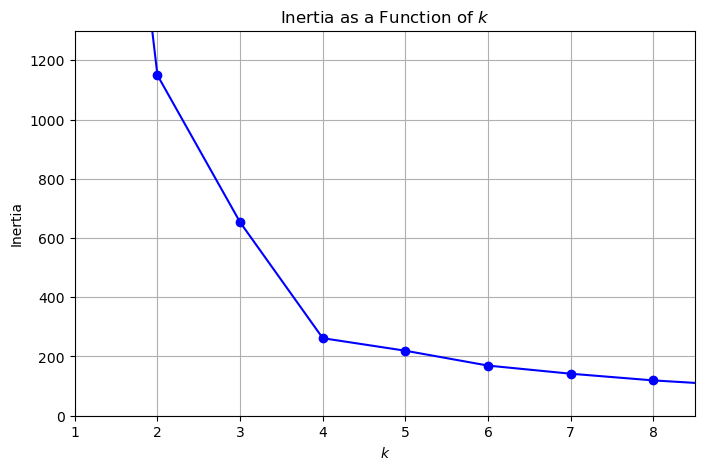

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.title("Inertia as a Function of $k$")
plt.axis([1, 8.5, 0, 1300])
plt.grid()
plt.show()

This plot can be used for the elbow method.

The idea is to look for the point where the inertia starts decreasing much more slowly.

This point is called the elbow, and it can be used as a rough estimate for the appropriate number of clusters.

The elbow method is useful, but it is not always precise.

A more informative metric is the silhouette score.

The silhouette score measures how well each instance fits within its assigned cluster compared to the nearest neighboring cluster.

In [38]:
from sklearn.metrics import silhouette_score

silhouette_score(X, kmeans.labels_)

0.6353422668284152

The silhouette score ranges from -1 to 1.

A higher score means the clusters are more compact and better separated.

Unlike inertia, the silhouette score does not always improve just because $k$ increases, so it can be more useful when choosing the number of clusters.

### Limits of k-Means

K-means is fast and scalable, but it has several limitations.

It requires the number of clusters $k$ to be specified in advance, and the result can depend on the initial centroid positions.

K-means also works best when clusters are roughly spherical and have similar sizes and densities.

Since it assigns instances based on distance to the nearest centroid, it can perform poorly when clusters are elongated, have different densities, or are not well separated.

Feature scaling is important because k-means is distance-based. If one feature has a much larger scale than others, it can dominate the clustering result.

### Using Clustering for Image Segmentation

Image segmentation is the task of dividing an image into multiple segments.

Here, we use k-means for color segmentation. Each pixel is treated as a data point represented by its RGB values.

K-means clusters similar colors together, then replaces each pixel with the color of its closest cluster center.

In [42]:
from sklearn.datasets import load_sample_image
import numpy as np

image = load_sample_image("flower.jpg")

print("Image shape:\n", image.shape)

Image shape:
 (427, 640, 3)


The image is stored as a 3D NumPy array.

The first dimension is the image height, the second dimension is the image width, and the third dimension represents the color channels.

Since this is an RGB image, each pixel has three values: red, green, and blue.

In [44]:
# Reshape the image into a 2D array where each row represents one pixel
# Each pixel has 3 features: red, green, and blue
X = image.reshape(-1, 3)

print("Reshaped image data:", X.shape)

Reshaped image data: (273280, 3)


In [45]:
# Cluster the RGB pixel values into 8 main color groups
kmeans = KMeans(n_clusters=6, random_state=42).fit(X)

# Replace each pixel with the RGB values of its closest cluster center
segmented_img = kmeans.cluster_centers_[kmeans.labels_]

# Reshape the segmented pixels back to the original image shape
segmented_img = segmented_img.reshape(image.shape)

# Convert cluster center RGB values back to image pixel format
segmented_img = segmented_img.astype(np.uint8)

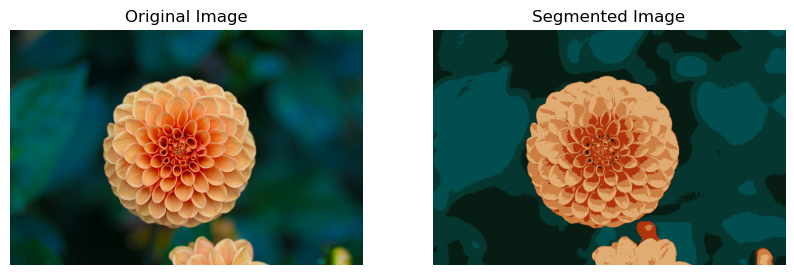

In [46]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented_img)
plt.title("Segmented Image")
plt.axis("off")

plt.show()

Using fewer clusters creates a simpler image with fewer colors.

However, small objects or rare colors may disappear if they do not get their own cluster.

### Using Clustering for Semi-Supervised Learning

Semi-supervised learning is useful when we have many unlabeled instances but only a few labeled instances.

Clustering can help by selecting representative instances to label.

Instead of labeling random instances, we can label examples that are close to cluster centroids.

In [91]:
from sklearn.datasets import load_digits

X_digits, y_digits = load_digits(return_X_y=True)

X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (1400, 64)
Test set shape: (397, 64)


First, we train a baseline model using only 50 labeled instances.

This simulates a situation where labels are expensive and only a small labeled dataset is available.

In [51]:
from sklearn.linear_model import LogisticRegression

n_labeled = 50

log_reg = LogisticRegression(max_iter=10_000)

log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

print("Accuracy using 50 random labeled instances:")
print(log_reg.score(X_test, y_test))

Accuracy using 50 random labeled instances:
0.7581863979848866


Instead of using 50 random labeled instances, we can use k-means to find 50 representative instances.

Each representative instance is the training example closest to a cluster centroid.

In [53]:
k = 50

kmeans = KMeans(n_clusters=k, random_state=42)

X_digits_dist = kmeans.fit_transform(X_train)

representative_digit_idx = X_digits_dist.argmin(axis=0)

X_representative_digits = X_train[representative_digit_idx]

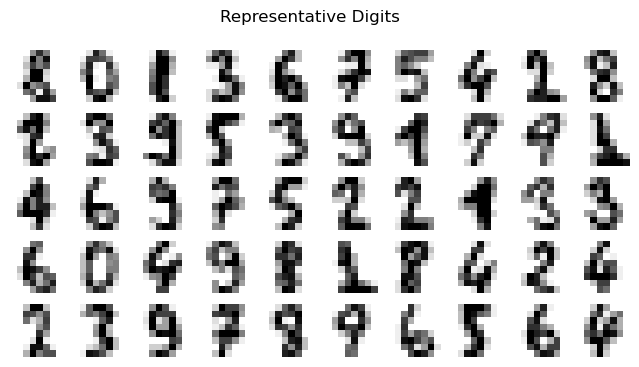

In [87]:
plt.figure(figsize=(8, 4))

for index, X_digit in enumerate(X_representative_digits):
    plt.subplot(5, 10, index + 1)
    plt.imshow(X_digit.reshape(8, 8), cmap="binary")
    plt.axis("off")

plt.suptitle("Representative Digits")
plt.show()

In a real semi-supervised learning setting, these representative images would be manually labeled by a human.

To keep this notebook reproducible, we use their true labels as if they were manually labeled.

In [116]:
y_representative_digits = y_train[representative_digit_idx]

log_reg = LogisticRegression(max_iter=10_000)

log_reg.fit(X_representative_digits, y_representative_digits)

print("Accuracy using 50 representative labeled instances:")
print(log_reg.score(X_test, y_test))

Accuracy using 50 representative labeled instances:
0.8312342569269522


Using representative instances can improve performance because the labeled examples cover the structure of the dataset more effectively than random examples.

We can go one step further by propagating each representative label to all instances in the same cluster.

This creates a larger labeled training set, but the propagated labels may contain errors if a cluster contains instances from multiple true classes.

In [114]:
y_train_propagated = np.empty(len(X_train), dtype=np.int64)

for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

log_reg = LogisticRegression(max_iter=10_000)

log_reg.fit(X_train, y_train_propagated)

print("Accuracy using propagated labels:")
print(log_reg.score(X_test, y_test))

Accuracy using propagated labels:
0.871536523929471


Label propagation can improve performance when the cluster structure aligns well with the true class structure.

However, it does not always help. If different classes are mixed inside the same cluster, propagated labels can introduce label noise and hurt the model.

### Active Learning

Active learning is another strategy for improving a model when labels are expensive.

Instead of asking humans to label random instances, the model selects the most useful or uncertain instances for labeling.

One common approach is uncertainty sampling, where the model requests labels for the examples it is least confident about.